In [28]:
%pip install pandas
import pandas as pd

pingPong_UHD60 = pd.read_csv('../../data/other/pingpong-2160@60.csv', header=None)
direct_UHD60 = pd.read_csv('../../data/other/direct-2160@60.csv', header=None)

pingPong_720p25 = pd.read_csv('../../data/other/pingpong-720@25.csv', header=None)
direct_720p25 = pd.read_csv('../../data/other/direct-720@25.csv', header=None)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [29]:
%pip install great_tables polars
import polars as pl
from great_tables import GT

  Using cached babel-2.17.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached babel-2.17.0-py3-none-any.whl.metadata (2.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.4 MB ? eta -:--:--Collecting zipp>=3.20 (from importlib-metadata->great_tables)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.0 MB/s  0:00:00 eta 0:00:01
Using cached babel-2.17.0-py3-none-any.whl (10.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.0 MB/s  0:00:00
Using cached babel-2.17.0-py3-none-any.whl (10.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/607.2 kB ? eta -:--:--Downloading commonmark-0.9.1-py2.py3-none-any.whl (51 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 5.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 5.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [great_tables] [Babel]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [great_tables]
Note: you may need to restart the kernel to use updated packages

In [30]:
pingPong_UHD60_rtt = pd.DataFrame(pingPong_UHD60.values[0][2:])
pingPong_UHD60_txTime = pd.DataFrame(pingPong_UHD60.values[1][2:])
pingPong_UHD60_rxTime = pd.DataFrame(pingPong_UHD60.values[2][2:])

latency_rtt2_pingPong_UHD60 = pingPong_UHD60_rtt/1000000/2
latency_direct_pingPong_UHD60 = pingPong_UHD60_rxTime.sub(pingPong_UHD60_txTime)/1000000

direct_UHD60_txTime = pd.DataFrame(direct_UHD60.values[1][2:])
direct_UHD60_rxTime = pd.DataFrame(direct_UHD60.values[2][2:])

latency_direct_UHD60 =  direct_UHD60_rxTime.sub(direct_UHD60_txTime)/1000000

In [31]:
pingPong_720p25_rtt = pd.DataFrame(pingPong_720p25.values[0][2:])
pingPong_720p25_txTime = pd.DataFrame(pingPong_720p25.values[1][2:])
pingPong_720p25_rxTime = pd.DataFrame(pingPong_720p25.values[2][2:])

latency_rtt2_pingPong_720p25 = pingPong_720p25_rtt/1000000/2
latency_direct_pingPong_720p25 = pingPong_720p25_rxTime.sub(pingPong_720p25_txTime)/1000000

direct_720p25_txTime = pd.DataFrame(direct_720p25.values[1][2:])
direct_720p25_rxTime = pd.DataFrame(direct_720p25.values[2][2:])

latency_direct_720p25 =  direct_720p25_rxTime.sub(direct_720p25_txTime)/1000000

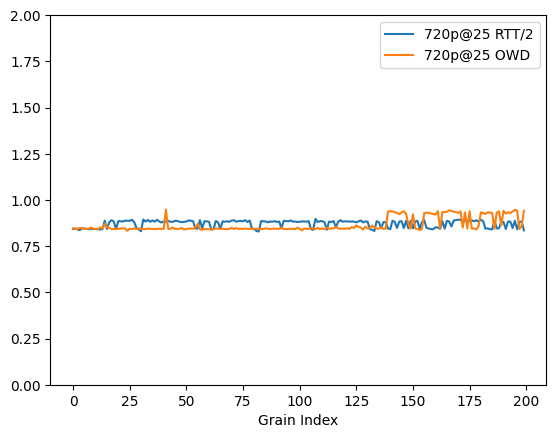

In [45]:
import matplotlib.pyplot as plt

# plt.plot(latency_rtt2_pingPong_UHD60, label='2160p@60 RTT/2')
# plt.plot(latency_direct_UHD60, label='2160p@60 OWD')

plt.plot(latency_rtt2_pingPong_720p25, label='720p@25 RTT/2')
plt.plot(latency_direct_720p25, label='720p@25 OWD')

plt.xlabel("Grain Index")
plt.ylim(0, 2)
plt.legend()
plt.show()

In [63]:
data_columns = ["Resolution", "Test Type", "Latency mean (ms)", "Latency stddev (ms)"]
latency_measurements_comp_table = make_table(latency_direct_720p25, latency_rtt2_pingPong_720p25, columns=data_columns) # type: ignore
(
    latency_measurements_comp_table
    .tab_header(
        title="Latency measurement methods comparison",
        subtitle="Inter-Host",
    )
)

/tmp/ipykernel_223607/1252980607.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  direct_mean = round(float(latency_direct_720p25.mean()), 4)
/tmp/ipykernel_223607/1252980607.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  direct_std = round(float(latency_direct_720p25.std()), 4)
/tmp/ipykernel_223607/1252980607.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rtt2_mean = round(float(latency_rtt2_pingPong_720p25.mean()), 4)
/tmp/ipykernel_223607/1252980607.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rtt2_std = round(float(latency_rtt2_pingPong_720p25.std()), 4)
/tmp/ipykernel_223

GT(_tbl_data=shape: (3, 4)
┌────────────┬──────────────────┬───────────────────┬─────────────────────┐
│ Resolution ┆ Test Type        ┆ Latency mean (ms) ┆ Latency stddev (ms) │
│ ---        ┆ ---              ┆ ---               ┆ ---                 │
│ str        ┆ str              ┆ f64               ┆ f64                 │
╞════════════╪══════════════════╪═══════════════════╪═════════════════════╡
│ 720p@25    ┆ Direct OWD       ┆ 0.8654            ┆ 0.0372              │
│ 720p@25    ┆ PingPong RTT/2   ┆ 0.8714            ┆ 0.0198              │
│ 720p@25    ┆ |Direct - RTT/2| ┆ 0.006             ┆ 0.0174              │
└────────────┴──────────────────┴───────────────────┴─────────────────────┘, _body=<great_tables._gt_data.Body object at 0x7eb1019b83e0>, _boxhead=Boxhead([ColInfo(var='Resolution', type=<ColInfoTypeEnum.default: 1>, column_label='Resolution', column_align='left', column_width=None), ColInfo(var='Test Type', type=<ColInfoTypeEnum.default: 1>, column_label='Test Type', column_align='left', column_width=None), ColInfo(var='Latency mean (ms)', type=<ColInfoTypeEnum.default: 1>, column_label='Latency mean (ms)', column_align='right', column_width=None), ColInfo(var='Latency stddev (ms)', type=<ColInfoTypeEnum.default: 1>, column_label='Latency stddev (ms)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7eb10128c6b0>, _spanners=Spanners([]), _heading=Heading(title='Latency measurement methods comparison', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7eb132230920>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table',

In [62]:
def make_table(latency_direct_720p25, latency_rtt2_pingPong_720p25, columns=None):
    import polars as pl
    from great_tables import GT
    direct_mean = round(float(latency_direct_720p25.mean()), 4)
    direct_std = round(float(latency_direct_720p25.std()), 4)
    rtt2_mean = round(float(latency_rtt2_pingPong_720p25.mean()), 4)
    rtt2_std = round(float(latency_rtt2_pingPong_720p25.std()), 4)
    comparison_mean = round(abs(direct_mean - rtt2_mean), 4)
    comparison_std = round(abs(direct_std - rtt2_std), 4)
    data = [
        ["720p@25", "Direct OWD", direct_mean, direct_std],
        ["720p@25", "PingPong RTT/2", rtt2_mean, rtt2_std],
        ["720p@25", "|Direct - RTT/2|", comparison_mean, comparison_std],
    ]
    if columns is None:
        columns = ["Resolution", "Test Type", "Latency mean (ms)", "Latency stddev (ms)"]
    df = pl.DataFrame(data, schema=columns)
    return GT(df)